In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/Celebrity Faces Dataset"

os.listdir(dataset_path)

['Will Smith',
 'Tom Cruise',
 'Scarlett Johansson',
 'Nicole Kidman',
 'Megan Fox',
 'Natalie Portman',
 'Kate Winslet',
 'Sandra Bullock',
 'Leonardo DiCaprio',
 'Robert Downey Jr',
 'Johnny Depp',
 'Jennifer Lawrence',
 'Hugh Jackman',
 'Tom Hanks']

In [ ]:
!pip install opencv-python

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [ ]:
#load the images
images = []
labels = []

for person in os.listdir(dataset_path):

    person_folder = os.path.join(dataset_path, person)

    if os.path.isdir(person_folder):

        for image_name in os.listdir(person_folder):

            image_path = os.path.join(person_folder, image_name)

            image = cv2.imread(image_path)

            if image is None:
                continue

            image = cv2.resize(image, (100,100))

            images.append(image)
            labels.append(person)

In [ ]:
print("Number of images:", len(images))
print("Number of labels:", len(labels))

Number of images: 1456
Number of labels: 1456


In [ ]:
#convert to numpy array
x=np.array(images)
y=np.array(labels)
print(x.shape)
print(y.shape)

(1456, 100, 100, 3)
(1456,)


In [ ]:
#normalize the images
x=x.astype("float32")/255.0

In [ ]:
#convert celebrity names to numbers
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

print(y[:10])

[13 13 13 13 13 13 13 13 13 13]


In [ ]:
#see how many celebrities are there
print("Number of classes:", len(np.unique(y)))
print(encoder.classes_)

Number of classes: 14
['Hugh Jackman' 'Jennifer Lawrence' 'Johnny Depp' 'Kate Winslet'
 'Leonardo DiCaprio' 'Megan Fox' 'Natalie Portman' 'Nicole Kidman'
 'Robert Downey Jr' 'Sandra Bullock' 'Scarlett Johansson' 'Tom Cruise'
 'Tom Hanks' 'Will Smith']


In [ ]:
print(len(images))
print(len(labels))

1456
1456


In [ ]:
X = np.array(images)
y = np.array(labels)

print(X.shape)
print(y.shape)

(1456, 100, 100, 3)
(1456,)


In [ ]:
X = X.astype('float32') / 255.0

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1164, 100, 100, 3)
(292, 100, 100, 3)


In [ ]:
#building the cnn model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(100,100,3)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(
    Dense(
        len(np.unique(y)),
        activation='softmax'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,733,582 (6.61 MB)

 Trainable params: 1,733,582 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Number of classes:", len(np.unique(y)))
print(encoder.classes_)

Number of classes: 14
['Hugh Jackman' 'Jennifer Lawrence' 'Johnny Depp' 'Kate Winslet'
 'Leonardo DiCaprio' 'Megan Fox' 'Natalie Portman' 'Nicole Kidman'
 'Robert Downey Jr' 'Sandra Bullock' 'Scarlett Johansson' 'Tom Cruise'
 'Tom Hanks' 'Will Smith']


In [ ]:
#build the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(100,100,3)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(
    Dense(
        len(np.unique(y)),
        activation='softmax'
    )
)



In [ ]:
#compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,733,582 (6.61 MB)

 Trainable params: 1,733,582 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#train the model
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 28s 680ms/step - accuracy: 0.1323 - loss: 2.6369 - val_accuracy: 0.1541 - val_loss: 2.5398
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 38s 635ms/step - accuracy: 0.1761 - loss: 2.4989 - val_accuracy: 0.2260 - val_loss: 2.3710
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 28s 778ms/step - accuracy: 0.2113 - loss: 2.3700 - val_accuracy: 0.2911 - val_loss: 2.2181
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 24s 632ms/step - accuracy: 0.2586 - loss: 2.1869 - val_accuracy: 0.2637 - val_loss: 2.1925
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 27s 711ms/step - accuracy: 0.3007 - loss: 2.0588 - val_accuracy: 0.3185 - val_loss: 1.9887
Epoch 6/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 547ms/step - accuracy: 0.3385 - loss: 1.9160 - val_accuracy: 0.3356 - val_loss: 1.9591
Epoch 7/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 22s 604ms/step - accuracy: 0.4046 - loss: 1.7273 - val_accuracy: 0.3664 - val_loss: 1.9107
Epoch 8/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 41s 594ms/step - accuracy: 0.4450 - loss: 1.5720 - val_accu

In [ ]:
#evaluating the model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)
#saving the model
model.save("celebrity_faces_dataset.h5")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.4212 - loss: 2.2737


Test Accuracy: 0.4212328791618347


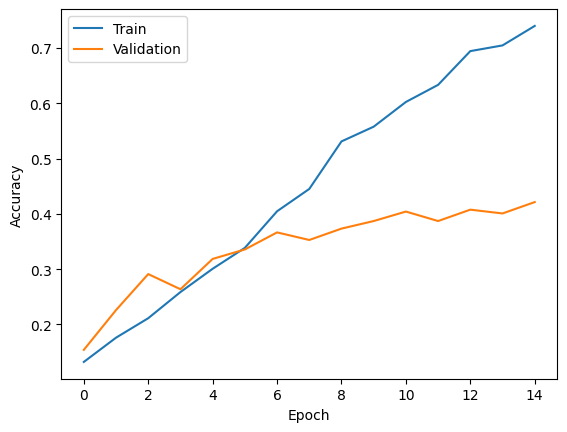

In [ ]:
#plot the accuracy graph
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
#predict a new image
model.save("celebrity_faces_dataset.keras")
from google.colab import files
uploaded = files.upload()

Saving tom.jpg to tom.jpg


In [ ]:
img = cv2.imread("tom.jpg")
img = cv2.resize(img, (100,100))
img = img / 255.0
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)

predicted_index = np.argmax(prediction)

name = encoder.inverse_transform([predicted_index])

print("Predicted Celebrity:", name[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Predicted Celebrity: Tom Cruise


In [ ]:
#prediction2:
#predict a new image
model.save("celebrity_faces_dataset.keras")
from google.colab import files
uploaded = files.upload()

Saving willSmith.jpg to willSmith.jpg


In [ ]:
img = cv2.imread("willSmith.jpg")
img = cv2.resize(img, (100,100))
img = img / 255.0
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)

predicted_index = np.argmax(prediction)

name = encoder.inverse_transform([predicted_index])

print("Predicted Celebrity:", name[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted Celebrity: Nicole Kidman


In [ ]:
#improving the model
#create an ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)
#train again:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test)
)


Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 28s 760ms/step - accuracy: 0.2225 - loss: 2.4432 - val_accuracy: 0.3459 - val_loss: 1.9531
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 24s 657ms/step - accuracy: 0.2680 - loss: 2.1989 - val_accuracy: 0.3596 - val_loss: 1.8335
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 40s 637ms/step - accuracy: 0.2680 - loss: 2.1697 - val_accuracy: 0.4178 - val_loss: 1.7929
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 25s 672ms/step - accuracy: 0.3179 - loss: 2.0136 - val_accuracy: 0.4281 - val_loss: 1.6646
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 26s 709ms/step - accuracy: 0.3230 - loss: 2.0001 - val_accuracy: 0.4418 - val_loss: 1.6930
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 23s 624ms/step - accuracy: 0.3411 - loss: 1.9464 - val_accuracy: 0.4418 - val_loss: 1.6866
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 25s 680ms/step - accuracy: 0.3471 - loss: 1.9509 - val_accuracy: 0.4315 - val_loss: 1.7607
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 24s 657ms/step - accuracy: 0.3436 - loss: 1.9200 - val_accu